In [ ]:
!nvidia-smi

# Muon Optimizer Development

This notebook is for developing and testing the Muon optimizer integration with the actual metamer generation code.

In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# Add the project root to the path so we can import our modules
project_root = os.path.abspath('')
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"Python path includes project root: {project_root in sys.path}")

Project root: /orcd/data/jhm/001/om2/rphess/projects/github.com/model_metamers_pytorch
Python path includes project root: True


In [2]:
# Import our custom modules
try:
    from analysis_scripts.input_helpers import generate_import_image_functions
    from robustness import custom_synthesis_losses
    print("✓ All custom modules imported successfully")
except Exception as e:
    print(f"✗ Failed to import custom modules: {e}")
    raise

### WARNING: UNABLE TO FIND IMAGENET FILES. IF TRANING IMAGENET MODELS, CHANGE PATH SPECIFIED IN analysis_scripts/default_paths.py. METAMERS CAN BE GENERATED WITHOUT THESE FILES. ###
### WARNING: UNABLE TO FIND JSIN AUDIO TRAINING DATASET FILES. IF TRAINING AUDIO MODELS, CHANGE PATH SPECIFIED IN analysis_scripts/default_paths.py. METAMERS CAN BE GENERATED WITHOUT THESE FILES ###
✓ All custom modules imported successfully


In [3]:
# Code from https://github.com/KellerJordan/cifar10-airbench/blob/0e6f9614572d7e8e3c259905aebc7196f91d5d79/research/clean_muon.py#L95
# adapted for image optimization by preston hess

def zeropower_via_newtonschulz5(G, steps=3, eps=1e-7):
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750,  2.0315)
    X = G.bfloat16()
    X /= (X.norm() + eps) # ensure top singular value <= 1
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X


class Muon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.24, momentum=0.6, eps=1e-8, debug=False):
        """
        Muon optimizer adapted for image optimization:
        - lr=0.24 (Muon works well with higher learning rates)
        - momentum=0.6 (recommended momentum)
        - eps=1e-8 (numerical stability)
        """
        defaults = dict(lr=lr, momentum=momentum, eps=eps, debug=debug)
        super().__init__(params, defaults)
        self._step_count = 0

    def step(self, closure=None):
        """Performs a single optimization step."""
        loss = None
        if closure is not None:
            loss = closure()

        self._step_count += 1
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            eps = group['eps']
            debug = group.get('debug', False)

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.data
                state = self.state[p]

                # Debug: Check gradient direction and magnitude
                if debug and self._step_count <= 5:
                    print(f"  Step {self._step_count}: grad_norm={grad.norm().item():.6f}, grad_mean={grad.mean().item():.6f}")

                # Initialize state
                if len(state) == 0:
                    state['momentum_buffer'] = torch.zeros_like(grad)

                # Nesterov-style momentum
                buf = state['momentum_buffer']
                buf.mul_(momentum).add_(grad)
                grad_with_momentum = grad.add(buf, alpha=momentum)

                # For image tensors, we need to be more careful with reshaping
                original_shape = grad_with_momentum.shape

                # Skip Muon's whitening for very small tensors or problematic shapes
                if grad_with_momentum.numel() < 4:
                    # Fall back to simple gradient descent for tiny tensors
                    update = grad_with_momentum
                    if debug and self._step_count <= 5:
                        print(f"  Using simple gradient (small tensor)")
                else:
                    try:
                        # Flatten to 2D for Muon's whitening operation
                        grad_2d = grad_with_momentum.view(grad_with_momentum.size(0), -1)

                        # Only apply whitening if we have enough dimensions
                        if grad_2d.size(1) >= 2:
                            update_2d = zeropower_via_newtonschulz5(grad_2d, eps=eps)
                            update = update_2d.view(original_shape)
                            if debug and self._step_count <= 5:
                                print(f"  Using Muon whitening: update_norm={update.norm().item():.6f}")
                        else:
                            # Fall back to normalized gradient for 1D-like tensors
                            update = grad_with_momentum / (grad_with_momentum.norm() + eps)
                            if debug and self._step_count <= 5:
                                print(f"  Using normalized gradient (1D-like)")
                    except Exception as e:
                        print(f"  Muon whitening failed, using normalized gradient: {e}")
                        update = grad_with_momentum / (grad_with_momentum.norm() + eps)

                # Apply the update (note: gradient descent goes in negative gradient direction)
                p.data.add_(update, alpha=-lr)

                if debug and self._step_count <= 5:
                    print(f"  Applied update: update_norm={update.norm().item():.6f}, lr={lr:.4f}")

        # Debug info every 20 steps
        if debug and self._step_count % 20 == 0:
            print(f"  Muon step {self._step_count}: lr={lr:.4f}, momentum={momentum:.3f}")

        return loss

In [4]:
# Test the updated Muon optimizer on a simple optimization problem
print("Testing updated Muon optimizer...")

# Create a simple optimization target (minimize distance to target image)
target_image = torch.randn(1, 3, 32, 32).cuda()
initial_image = torch.randn(1, 3, 32, 32, requires_grad=True).cuda()

# Test with both optimizers
optimizers_test = {
    "sgd": torch.optim.SGD([initial_image.clone().detach().requires_grad_(True)], lr=0.1),
    "muon": Muon([initial_image.clone().detach().requires_grad_(True)], lr=0.02)
}

for opt_name, optimizer in optimizers_test.items():
    print(f"\nTesting {opt_name.upper()} optimizer:")
    
    # Get the parameter being optimized
    param = list(optimizer.param_groups[0]['params'])[0]
    
    losses = []
    for step in range(10):
        optimizer.zero_grad()
        
        # Simple L2 loss to target
        loss = torch.nn.functional.mse_loss(param, target_image)
        loss.backward()
        
        print(f"  Step {step}: loss = {loss.item():.6f}")
        losses.append(loss.item())
        
        optimizer.step()
    
    # Check if loss is decreasing
    if losses[-1] < losses[0]:
        print(f"  ✓ {opt_name.upper()} is working: loss decreased from {losses[0]:.6f} to {losses[-1]:.6f}")
    else:
        print(f"  ✗ {opt_name.upper()} may have issues: loss went from {losses[0]:.6f} to {losses[-1]:.6f}")

print("\nOptimizer test completed!")


Testing updated Muon optimizer...

Testing SGD optimizer:
  Step 0: loss = 2.037129
  Step 1: loss = 2.036864
  Step 2: loss = 2.036599
  Step 3: loss = 2.036334
  Step 4: loss = 2.036068
  Step 5: loss = 2.035803
  Step 6: loss = 2.035538
  Step 7: loss = 2.035273
  Step 8: loss = 2.035008
  Step 9: loss = 2.034743
  ✓ SGD is working: loss decreased from 2.037129 to 2.034743

Testing MUON optimizer:
  Step 0: loss = 2.037129
  Step 1: loss = 2.036392
  Step 2: loss = 2.035656
  Step 3: loss = 2.034888
  Step 4: loss = 2.034121
  Step 5: loss = 2.033354
  Step 6: loss = 2.032586
  Step 7: loss = 2.031843
  Step 8: loss = 2.031100
  Step 9: loss = 2.030333
  ✓ MUON is working: loss decreased from 2.037129 to 2.030333

Optimizer test completed!


In [5]:
# Import the build_network module
import importlib.util

model_dir = 'model_analysis_folders/visual_networks/resnet50_l2_3_robust'
build_network_path = os.path.join(project_root, model_dir, 'build_network.py')

try:
    # Import build_network module
    build_network_spec = importlib.util.spec_from_file_location(
        "build_network", build_network_path
    )
    build_network = importlib.util.module_from_spec(build_network_spec)
    build_network_spec.loader.exec_module(build_network)

    # Load the model
    model, ds, metamer_layers = build_network.main(return_metamer_layers=True)
    print(f"✓ Model loaded successfully")
    print(f"  Model type: {type(model)}")
    print(f"  Metamer layers: {metamer_layers}")

except Exception as e:
    print(f"✗ Failed to load model: {e}")
    raise

=> loading checkpoint '/orcd/data/jhm/001/om2/rphess/projects/github.com/model_metamers_pytorch/model_analysis_folders/visual_networks/pytorch_checkpoints/resnet50_imagenet_l2_3_0_robustness.pt'
mapping normalizer.new_mean to preproc.normalize.new_mean
mapping normalizer.new_std to preproc.normalize.new_std
mapping attacker.normalize.new_mean to attacker.preproc.normalize.new_mean
mapping attacker.normalize.new_std to attacker.preproc.normalize.new_std
=> loaded checkpoint '/orcd/data/jhm/001/om2/rphess/projects/github.com/model_metamers_pytorch/model_analysis_folders/visual_networks/pytorch_checkpoints/resnet50_imagenet_l2_3_0_robustness.pt' (epoch 105)
✓ Model loaded successfully
  Model type: <class 'robustness.attacker.AttackerModel'>
  Metamer layers: ['input_after_preproc', 'conv1_relu1_fake_relu', 'layer1_fake_relu', 'layer2_fake_relu', 'layer3_fake_relu', 'layer4_fake_relu', 'avgpool', 'final']


In [6]:
# Load test image using the same functions as the metamer script
SIDX = 0  # Test with first image
INPUTIMAGEFUNCNAME = "400_16_class_imagenet_val"

try:
    # Generate import image function
    INPUTIMAGEFUNC = generate_import_image_functions(
        INPUTIMAGEFUNCNAME, data_format="NCHW"
    )
    
    # Load image
    image_dict = INPUTIMAGEFUNC(SIDX)
    image_dict["image_orig"] = image_dict["image"]
    
    # Preprocess image (same as metamer script)
    def preproc_image(image, image_dict):
        """The image into the pytorch model should be between 0-1"""
        if image_dict["max_value_image_set"] == 255:
            image = image / 255.0
        return image
    
    image_dict["image"] = preproc_image(image_dict["image"], image_dict)
    
    # Add batch dimension
    im = torch.tensor(np.expand_dims(image_dict["image"], 0)).float().contiguous()
    
    print(f"✓ Image loaded successfully")
    print(f"  Image shape: {im.shape}")
    print(f"  Image range: [{im.min():.3f}, {im.max():.3f}]")
    print(f"  Image filename: {image_dict.get('filename_short', 'unknown')}")
    
except Exception as e:
    print(f"✗ Failed to load image: {e}")
    raise

✓ Image loaded successfully
  Image shape: torch.Size([1, 3, 224, 224])
  Image range: [0.000, 1.000]
  Image filename: 0_0_airplane_n02690373_00030531.JPEG


In [7]:
# Patch the robustness library to use our custom Muon optimizer
import robustness.attacker as attacker_module
from tqdm import tqdm

def patch_attacker_for_custom_muon():
    """Patch the attacker to completely replace the optimization loop for Muon"""

    # Get the original Attacker class
    AttackerClass = attacker_module.Attacker

    # Store original forward method
    original_forward = AttackerClass.forward

    def patched_forward(self, x, target, *args, **kwargs):
        """Patched forward method that uses our custom Muon"""

        # Extract optimizer from kwargs
        optimizer_type = kwargs.get('optimizer', 'sgd')

        # If not using muon, use original implementation
        if optimizer_type.lower() != 'muon':
            return original_forward(self, x, target, *args, **kwargs)

        # Custom Muon implementation
        print("Using custom Muon optimizer implementation...")

        # Extract parameters (similar to original implementation)
        constraint = kwargs.get('constraint', '2')
        eps = kwargs.get('eps', 1000)
        step_size = kwargs.get('step_size', 1.0)
        iterations = kwargs.get('iterations', 100)
        random_start = kwargs.get('random_start', False)
        do_tqdm = kwargs.get('do_tqdm', False)
        targeted = kwargs.get('targeted', False)
        custom_loss = kwargs.get('custom_loss', None)
        should_preproc = kwargs.get('should_preproc', True)
        orig_input = kwargs.get('orig_input', None)
        use_best = kwargs.get('use_best', True)
        return_image = kwargs.get('return_image', True)

        # Setup (same as original)
        if orig_input is None:
            orig_input = x.detach()
        orig_input = orig_input.cuda()

        m = -1 if targeted else 1
        criterion = torch.nn.CrossEntropyLoss(reduction="none").cuda()

        # Import step class
        STEPS = {
            "inf": attacker_module.attack_steps.LinfStep,
            "2": attacker_module.attack_steps.L2Step,
            "unconstrained": attacker_module.attack_steps.UnconstrainedStep,
        }
        step_class = STEPS[constraint] if isinstance(constraint, str) else constraint
        step = step_class(
            eps=eps,
            orig_input=orig_input,
            step_size=step_size,
            min_value=self.dataset_min_value,
            max_value=self.dataset_max_value,
        )

        def calc_loss(inp, target):
            """Calculate loss"""
            if should_preproc:
                inp = self.preproc(inp)
            output = self.model(inp)
            if custom_loss:
                return custom_loss(self.model, inp, target)
            return criterion(output, target), output

        # Random start
        if random_start:
            x = step.random_perturb(x)

        # Initialize our custom Muon optimizer with debug mode for first few steps
        x_param = x.clone().detach().requires_grad_(True)
        muon_optimizer = Muon([x_param], lr=step_size, debug=False)  # Set to True for detailed debugging

        if do_tqdm:
            iterator = tqdm(range(iterations))
        else:
            iterator = range(iterations)

        best_loss = None
        best_x = None

        def replace_best(loss, bloss, x, bx):
            if bloss is None:
                bx = x.clone().detach()
                bloss = loss.clone().detach()
            else:
                replace = m * bloss < m * loss
                bx[replace] = x[replace].clone().detach()
                bloss[replace] = loss[replace]
            return bloss, bx

        for i in iterator:
            # Forward pass
            losses, out = calc_loss(step.to_image(x_param), target)
            loss = torch.mean(losses)
    
            # Debug: Print loss progression
            if i < 5 or i % 50 == 0:
                print(f"  Iteration {i}: loss = {loss.item():.6f}, m = {m}, targeted = {targeted}")

            muon_optimizer.zero_grad()

            if targeted:
                # Targeted: minimize loss, so use loss as-is (gradient descent will minimize)
                loss.backward()
                if i < 3:
                    print(f"  Targeted mode: minimizing loss directly")
            else:
                # Untargeted: maximize loss, so negate it (gradient descent will minimize the negative = maximize original)
                (-loss).backward()
                if i < 3:
                    print(f"  Untargeted mode: maximizing loss by minimizing -loss")

            # Debug: Check gradient after backward
            if i < 3:
                grad_norm = x_param.grad.norm().item()
                grad_mean = x_param.grad.mean().item()
                print(f"  Iter {i}: grad_norm={grad_norm:.6f}, grad_mean={grad_mean:.6f}")

            # Apply optimizer step
            muon_optimizer.step()

            # Project back to feasible set
            with torch.no_grad():
                x_param.data = step.project(x_param.data)

                # Update best
                args_best = [losses, best_loss, x_param, best_x]
                best_loss, best_x = replace_best(*args_best) if use_best else (losses, x_param)

            if do_tqdm and hasattr(iterator, 'set_description'):
                iterator.set_description(f"Current loss: {loss.item():.6f}")

        # Return result
        if not use_best:
            ret = x_param.clone().detach()
            return step.to_image(ret) if return_image else ret

        with torch.no_grad():
            losses, _ = calc_loss(step.to_image(x_param), target)
            args_best = [losses, best_loss, x_param, best_x]
            best_loss, best_x = replace_best(*args_best)
            return step.to_image(best_x) if return_image else best_x

    # Replace the forward method
    AttackerClass.forward = patched_forward
    print("✓ Attacker patched with custom Muon optimization loop")

# Apply the patch
patch_attacker_for_custom_muon()


✓ Attacker patched with custom Muon optimization loop


In [8]:
# Move model to GPU and get original activations
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.cuda()
model.eval()

# Get original activations
with torch.no_grad():
    (predictions, rep, all_outputs), orig_im = model(
        im.cuda(), with_latent=True, fake_relu=True
    )

print(f"✓ Original activations computed")
print(f"  Available layers: {list(all_outputs.keys())}")
print(f"  Metamer layers: {metamer_layers}")

Using device: cuda
✓ Original activations computed
  Available layers: ['input_after_preproc', 'conv1', 'bn1', 'conv1_relu1_fake_relu', 'conv1_relu1', 'maxpool1', 'layer1_fake_relu', 'layer1', 'layer2_fake_relu', 'layer2', 'layer3_fake_relu', 'layer3', 'layer4_fake_relu', 'layer4', 'avgpool', 'final']
  Metamer layers: ['input_after_preproc', 'conv1_relu1_fake_relu', 'layer1_fake_relu', 'layer2_fake_relu', 'layer3_fake_relu', 'layer4_fake_relu', 'avgpool', 'final']


In [18]:
# Test our modified attacker with Muon optimizer
# We'll test with a single layer first
layer_to_invert = metamer_layers[7]  # Use first layer
print(f"Testing with layer: {layer_to_invert}")

# Set up synthesis parameters (same as metamer script)
synth_kwargs = {
    "custom_loss": custom_synthesis_losses.LOSSES["inversion_loss_layer"](
        layer_to_invert, normalize_loss=True
    ),
    "constraint": "2",
    "eps": 100000,
    "step_size": 0.24,  # Learning rate for Muon (higher learning rates work better with Muon)
    "iterations": 2000,  # Reduced for testing
    "do_tqdm": True,  # Enable progress bar to see optimization progress
    "targeted": True,
    "use_best": False,
    "optimizer": "muon",
}

print("Synthesis parameters:")
for key, value in synth_kwargs.items():
    print(f"  {key}: {value}")

Testing with layer: final
Synthesis parameters:
  custom_loss: InversionLossLayer()
  constraint: 2
  eps: 100000
  step_size: 0.24
  iterations: 2000
  do_tqdm: True
  targeted: True
  use_best: False
  optimizer: muon


In [20]:
# Prepare input for metamer generation
# Use same noise initialization as metamer script
NOISE_SCALE = 1/20
init_noise_mean = 0.5

# Initialize noise input
im_n_initialized = (
    (torch.randn_like(im) * NOISE_SCALE + init_noise_mean).detach().cpu().numpy()
)

# Clamp to dataset range
im_n = torch.clamp(
    torch.from_numpy(im_n_initialized), ds.min_value, ds.max_value
).cuda()

# Get target representation
invert_rep = (
    all_outputs[layer_to_invert]
    .contiguous()
    .view(all_outputs[layer_to_invert].size(0), -1)
)

print(f"✓ Input prepared for metamer generation")
print(f"  Noise input shape: {im_n.shape}")
print(f"  Target representation shape: {invert_rep.shape}")
print(f"  Noise input range: [{im_n.min():.3f}, {im_n.max():.3f}]")

✓ Input prepared for metamer generation
  Noise input shape: torch.Size([1, 3, 224, 224])
  Target representation shape: torch.Size([1, 1000])
  Noise input range: [0.273, 0.697]


In [21]:
# Test Muon with different learning rates on the actual metamer generation task
print("=== Testing Muon Learning Rates on Metamer Generation ===")

# Test higher learning rates suitable for Muon on the actual task
metamer_learning_rates = [2.0, 1.5, 1.0, 0.5, 0.24, 0.1, 0.05, 0.02, 0.01]
metamer_test_iterations = 20

metamer_results = {}

for lr in metamer_learning_rates:
    print(f"\nTesting Muon with lr={lr} on metamer generation...")
    
    # Reset input
    im_n_test = torch.clamp(
        torch.from_numpy(im_n_initialized), ds.min_value, ds.max_value
    ).cuda()
    
    # Create test synthesis kwargs
    synth_kwargs_lr_test = synth_kwargs.copy()
    synth_kwargs_lr_test["step_size"] = lr
    synth_kwargs_lr_test["iterations"] = metamer_test_iterations
    synth_kwargs_lr_test["do_tqdm"] = False  # Disable progress bar for cleaner output
    synth_kwargs_lr_test["optimizer"] = "muon"
    
    try:
        import time
        start_time = time.time()
        
        (predictions_out, rep_out, all_outputs_out), xadv = model(
            im_n_test,
            invert_rep.clone(),
            make_adv=True,
            **synth_kwargs_lr_test,
            with_latent=True,
            fake_relu=True,
        )
        
        end_time = time.time()
        
        # Compute final loss
        def calc_loss(model, inp, target, custom_loss, should_preproc=True):
            """Calculate loss (same as metamer script)"""
            if should_preproc:
                inp = model.preproc(inp)
            return custom_loss(model.model, inp, target)
        
        final_loss, _ = calc_loss(
            model, xadv, invert_rep.clone(), synth_kwargs_lr_test["custom_loss"]
        )
        
        metamer_results[lr] = {
            "final_loss": final_loss.item(),
            "time": end_time - start_time,
            "success": True
        }
        
        print(f"  ✓ Success: final_loss = {final_loss.item():.6f}, time = {metamer_results[lr]['time']:.2f}s")
        
    except Exception as e:
        print(f"  ✗ Failed: {e}")
        metamer_results[lr] = {
            "error": str(e),
            "success": False
        }

# Find the best learning rate for metamer generation
print(f"\n=== Metamer Generation Learning Rate Results ===")
successful_lrs = [lr for lr, result in metamer_results.items() if result.get('success', False)]

if successful_lrs:
    best_metamer_lr = min(successful_lrs, key=lambda lr: metamer_results[lr]['final_loss'])
    print(f"✓ Best learning rate for metamer generation: {best_metamer_lr}")
    print(f"  Final loss: {metamer_results[best_metamer_lr]['final_loss']:.6f}")
    print(f"  Time: {metamer_results[best_metamer_lr]['time']:.2f}s")
    
    # Update the main synthesis kwargs with the best learning rate
    synth_kwargs["step_size"] = best_metamer_lr
    print(f"\n✓ Updated main synthesis kwargs to use lr={best_metamer_lr}")
else:
    print("✗ No learning rates worked for metamer generation")
    print("Will keep the current conservative learning rate of 0.001")


=== Testing Muon Learning Rates on Metamer Generation ===

Testing Muon with lr=2.0 on metamer generation...
Using custom Muon optimizer implementation...
  Iteration 0: loss = 1.004987, m = -1, targeted = True
  Targeted mode: minimizing loss directly
  Iter 0: grad_norm=0.013283, grad_mean=-0.000000
  Iteration 1: loss = 0.984739, m = -1, targeted = True
  Targeted mode: minimizing loss directly
  Iter 1: grad_norm=0.014058, grad_mean=-0.000000
  Iteration 2: loss = 0.965079, m = -1, targeted = True
  Targeted mode: minimizing loss directly
  Iter 2: grad_norm=0.012939, grad_mean=-0.000000
  Iteration 3: loss = 0.947304, m = -1, targeted = True
  Iteration 4: loss = 0.932460, m = -1, targeted = True
  ✓ Success: final_loss = 0.752993, time = 0.82s

Testing Muon with lr=1.5 on metamer generation...
Using custom Muon optimizer implementation...
  Iteration 0: loss = 1.004987, m = -1, targeted = True
  Targeted mode: minimizing loss directly
  Iter 0: grad_norm=0.013283, grad_mean=-0.00

In [22]:
# Test both optimizers and compare performance
optimizers_to_test = ["sgd", "muon"]

results = {}

for optimizer_name in optimizers_to_test:
    print(f"\nTesting {optimizer_name.upper()} optimizer...")

    # Reset synthesis kwargs with appropriate parameters for each optimizer
    synth_kwargs_test = synth_kwargs.copy()
    synth_kwargs_test["optimizer"] = optimizer_name

    # Adjust learning rate for different optimizers
    if optimizer_name == "sgd":
        synth_kwargs_test["step_size"] = 1.0   # SGD learning rate

    # Reset input
    im_n = torch.clamp(
        torch.from_numpy(im_n_initialized), ds.min_value, ds.max_value
    ).cuda()

    try:
        # Time the optimization
        import time
        start_time = time.time()

        (predictions_out, rep_out, all_outputs_out), xadv = model(
            im_n,
            invert_rep.clone(),
            make_adv=True,
            **synth_kwargs_test,
            with_latent=True,
            fake_relu=True,
        )

        end_time = time.time()

        # Compute final loss
        final_loss, _ = calc_loss(
            model, xadv, invert_rep.clone(), synth_kwargs_test["custom_loss"]
        )

        results[optimizer_name] = {
            "xadv": xadv,
            "final_loss": final_loss.item(),
            "time": end_time - start_time,
            "predictions_out": predictions_out,
            "all_outputs_out": all_outputs_out
        }

        print(f"  ✓ Completed in {results[optimizer_name]['time']:.2f}s")
        print(f"  Final loss: {results[optimizer_name]['final_loss']:.6f}")
        print(f"  Learning rate used: {synth_kwargs_test['step_size']}")

    except Exception as e:
        print(f"  ✗ Failed: {e}")
        import traceback
        traceback.print_exc()
        results[optimizer_name] = {"error": str(e)}


Testing SGD optimizer...


Current loss: 0.10689577460289001: 100%|██████████| 2000/2000 [00:29<00:00, 68.44it/s]


  ✓ Completed in 29.23s
  Final loss: 0.105898
  Learning rate used: 1.0

Testing MUON optimizer...
Using custom Muon optimizer implementation...


Current loss: 0.897965:   0%|          | 5/2000 [00:00<00:48, 41.30it/s]

  Iteration 0: loss = 1.004987, m = -1, targeted = True
  Targeted mode: minimizing loss directly
  Iter 0: grad_norm=0.013283, grad_mean=-0.000000
  Iteration 1: loss = 0.984728, m = -1, targeted = True
  Targeted mode: minimizing loss directly
  Iter 1: grad_norm=0.014080, grad_mean=-0.000000
  Iteration 2: loss = 0.965098, m = -1, targeted = True
  Targeted mode: minimizing loss directly
  Iter 2: grad_norm=0.012947, grad_mean=-0.000000
  Iteration 3: loss = 0.948320, m = -1, targeted = True
  Iteration 4: loss = 0.933294, m = -1, targeted = True


...

  Iteration 1900: loss = 0.095112, m = -1, targeted = True


Current loss: 0.094701:  98%|█████████▊| 1960/2000 [00:33<00:00, 60.82it/s]

  Iteration 1950: loss = 0.095620, m = -1, targeted = True


Current loss: 0.094564: 100%|██████████| 2000/2000 [00:34<00:00, 57.75it/s]


  ✓ Completed in 34.64s
  Final loss: 0.095579
  Learning rate used: 2.0



=== Model Predictions and Visualization ===
SGD metamer - Top prediction: Class 404 (prob: 0.969)
MUON metamer - Top prediction: Class 404 (prob: 0.977)


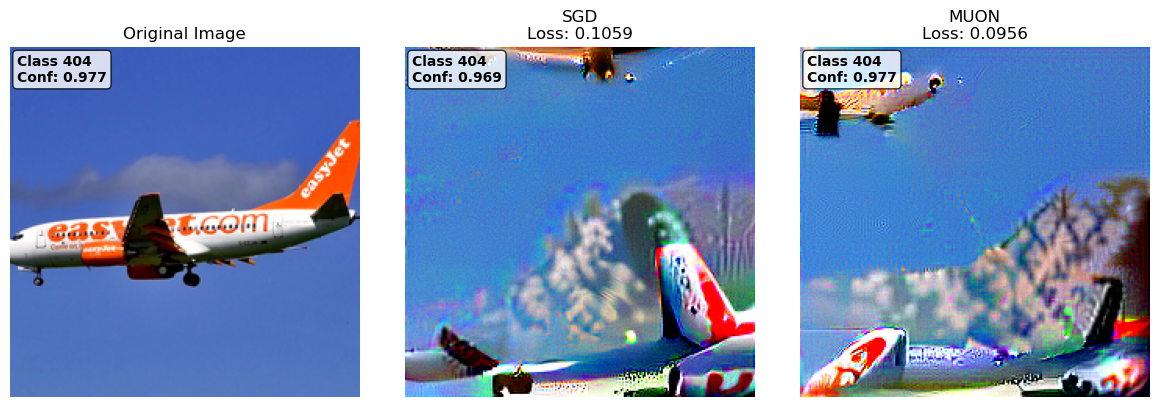


OPTIMIZATION RESULTS SUMMARY
ORIGINAL IMAGE:
  Top prediction: Class 404 (confidence: 0.977)
  Top 3: [(404, 0.976709), (908, 0.016237576), (895, 0.006789128)]

SGD: SUCCESS
  Final loss: 0.105898
  Time: 29.23s
  Top prediction: Class 404 (confidence: 0.969)
  ✓ Classification MATCHES original (Class 404)
MUON: SUCCESS
  Final loss: 0.095579
  Time: 34.64s
  Top prediction: Class 404 (confidence: 0.977)
  ✓ Classification MATCHES original (Class 404)

----------------------------------------
OPTIMIZER COMPARISON:
SGD vs MUON:
  Loss difference (muon - sgd): -0.010318
  Time difference (muon - sgd): +5.41s
  → MUON achieved lower loss


In [23]:
# Enhanced visualization with classification results
def get_model_predictions(image_tensor, model, top_k=5):
    """Get model predictions for an image tensor"""
    with torch.no_grad():
        if len(image_tensor.shape) == 3:
            image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension

        # Get model predictions
        outputs, _ = model(image_tensor.cuda(), with_latent=False)
        probs = torch.nn.functional.softmax(outputs, dim=1)

        # Get top-k predictions
        top_probs, top_indices = torch.topk(probs, top_k)

        return top_probs[0].cpu().numpy(), top_indices[0].cpu().numpy()

def plot_image_with_combined_info(ax, image_array, title, predictions=None, loss=None):
    """Plot image with both prediction and loss information"""
    # Ensure image is in correct format for display
    if image_array.shape[0] == 3:  # NCHW format
        image_array = np.rollaxis(image_array, 0, 3)

    ax.imshow(np.clip(image_array, 0, 1))

    # Combine prediction and loss info
    info_lines = []
    if predictions is not None:
        probs, indices = predictions
        info_lines.append(f"Class {indices[0]}")
        info_lines.append(f"Conf: {probs[0]:.3f}")

    if info_lines:
        info_text = "\n".join(info_lines)
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                verticalalignment='top', fontsize=10, fontweight='bold')

    ax.set_title(title)
    ax.axis('off')

# Create visualization
print("\n=== Model Predictions and Visualization ===")
n_optimizers = len(results)

# Create visualization with single row: original + optimizers
fig, axes = plt.subplots(1, n_optimizers + 1, figsize=(4 * (n_optimizers + 1), 4))

if n_optimizers == 0:
    print("No results to visualize")
else:
    # Get original image predictions
    orig_img = im.squeeze().cpu().numpy()
    orig_predictions = get_model_predictions(im, model)
    
    # Plot original image
    plot_image_with_combined_info(axes[0], orig_img, "Original Image", orig_predictions)

    # Plot each optimizer result
    for i, (optimizer_name, result) in enumerate(results.items()):
        if "error" in result:
            # Show error
            axes[i + 1].text(0.5, 0.5, f"Error:\n{result['error']}", 
                            ha='center', va='center', transform=axes[i + 1].transAxes)
            axes[i + 1].set_title(f"{optimizer_name.upper()} (Failed)")
            axes[i + 1].axis('off')
        else:
            xadv_img = result["xadv"].squeeze().cpu().numpy()
            metamer_predictions = get_model_predictions(result["xadv"], model)
            
            print(f"{optimizer_name.upper()} metamer - Top prediction: Class {metamer_predictions[1][0]} (prob: {metamer_predictions[0][0]:.3f})")
            
            # Plot image with both prediction and loss info
            plot_image_with_combined_info(axes[i + 1], xadv_img, 
                                        f"{optimizer_name.upper()}\nLoss: {result['final_loss']:.4f}",
                                        predictions=metamer_predictions, loss=result['final_loss'])

plt.tight_layout()
plt.show()

# Enhanced comparison summary
print("\n" + "=" * 60)
print("OPTIMIZATION RESULTS SUMMARY")
print("=" * 60)

# Original image classification
orig_predictions = get_model_predictions(im, model)
print(f"ORIGINAL IMAGE:")
print(f"  Top prediction: Class {orig_predictions[1][0]} (confidence: {orig_predictions[0][0]:.3f})")
print(f"  Top 3: {[(idx, prob) for idx, prob in zip(orig_predictions[1][:3], orig_predictions[0][:3])]}")

print()

# Results for each optimizer
for optimizer_name, result in results.items():
    if "error" in result:
        print(f"{optimizer_name.upper()}: FAILED")
        print(f"  Error: {result['error']}")
    else:
        metamer_predictions = get_model_predictions(result["xadv"], model)
        
        print(f"{optimizer_name.upper()}: SUCCESS")
        print(f"  Final loss: {result['final_loss']:.6f}")
        print(f"  Time: {result['time']:.2f}s")
        print(f"  Top prediction: Class {metamer_predictions[1][0]} (confidence: {metamer_predictions[0][0]:.3f})")
        
        # Check if classification matches original
        orig_class = orig_predictions[1][0]
        metamer_class = metamer_predictions[1][0]
        if orig_class == metamer_class:
            print(f"  ✓ Classification MATCHES original (Class {orig_class})")
        else:
            print(f"  ✗ Classification DIFFERS: Original={orig_class}, Metamer={metamer_class}")

# Compare optimizers if multiple succeeded
successful_results = {name: result for name, result in results.items() if "error" not in result}
if len(successful_results) > 1:
    print(f"\n{'-' * 40}")
    print("OPTIMIZER COMPARISON:")
    
    optimizers = list(successful_results.keys())
    for i in range(len(optimizers)):
        for j in range(i + 1, len(optimizers)):
            opt1, opt2 = optimizers[i], optimizers[j]
            loss_diff = successful_results[opt2]['final_loss'] - successful_results[opt1]['final_loss']
            time_diff = successful_results[opt2]['time'] - successful_results[opt1]['time']
            
            print(f"{opt1.upper()} vs {opt2.upper()}:")
            print(f"  Loss difference ({opt2} - {opt1}): {loss_diff:+.6f}")
            print(f"  Time difference ({opt2} - {opt1}): {time_diff:+.2f}s")
            
            if abs(loss_diff) < 1e-4:
                print(f"  → Similar final loss")
            elif loss_diff < 0:
                print(f"  → {opt2.upper()} achieved lower loss")
            else:
                print(f"  → {opt1.upper()} achieved lower loss")

print("=" * 60)

=== Band-Pass Analysis with Model Classification ===
Processing frequency bands...
  Band 1: 1.0 - 2.8 Hz
    → Top prediction: Class 111 (confidence: 0.028)
  Band 2: 2.8 - 7.6 Hz
    → Top prediction: Class 508 (confidence: 0.019)
  Band 3: 7.6 - 20.9 Hz
    → Top prediction: Class 508 (confidence: 0.075)
  Band 4: 20.9 - 57.5 Hz
    → Top prediction: Class 815 (confidence: 0.045)
  Band 5: 57.5 - 158.4 Hz
    → Top prediction: Class 815 (confidence: 0.026)

Original Muon metamer: Class 404 (confidence: 0.898)


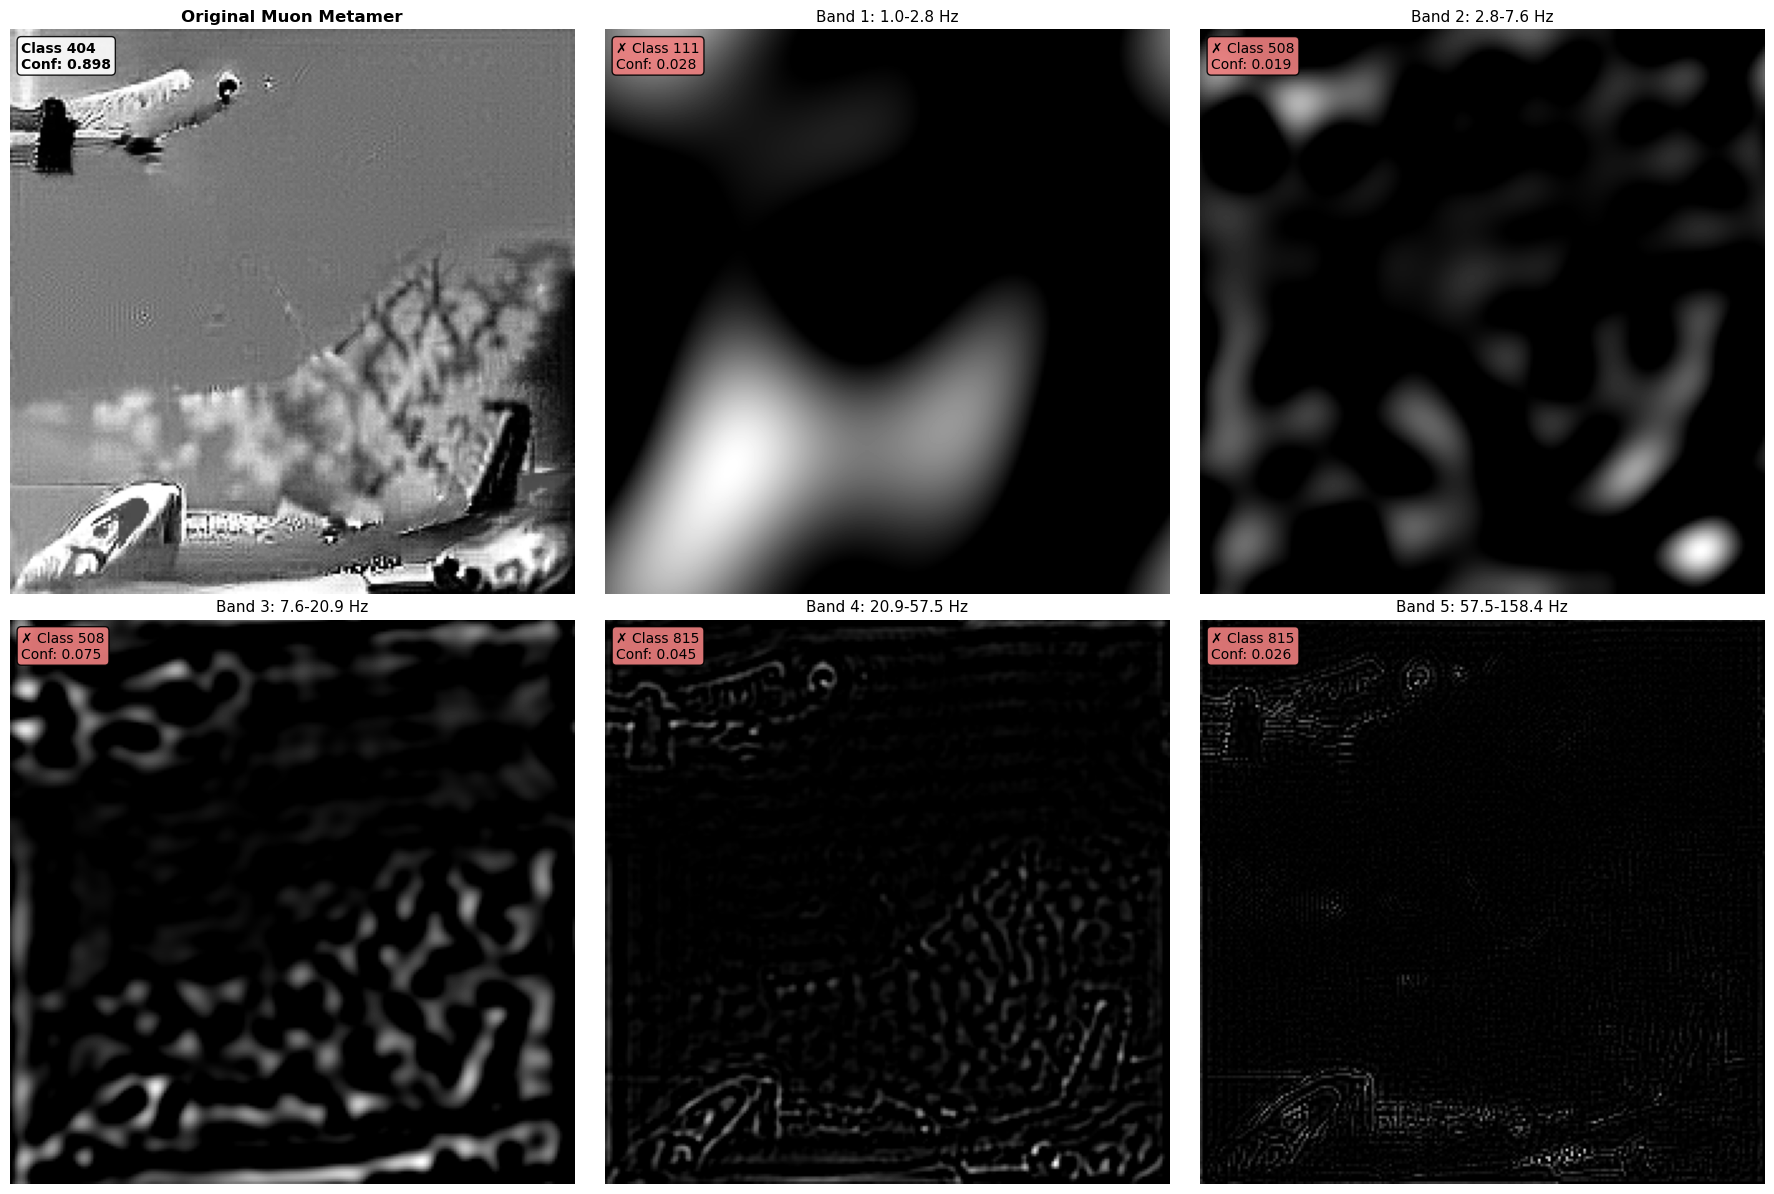


FREQUENCY BAND CLASSIFICATION ANALYSIS
Original Muon Metamer: Class 404 (confidence: 0.898)

Band 1: 1.0 - 2.8 Hz
  ✗ DIFFER: Class 111 (confidence: 0.028)
    Expected: Class 404

Band 2: 2.8 - 7.6 Hz
  ✗ DIFFER: Class 508 (confidence: 0.019)
    Expected: Class 404

Band 3: 7.6 - 20.9 Hz
  ✗ DIFFER: Class 508 (confidence: 0.075)
    Expected: Class 404

Band 4: 20.9 - 57.5 Hz
  ✗ DIFFER: Class 815 (confidence: 0.045)
    Expected: Class 404

Band 5: 57.5 - 158.4 Hz
  ✗ DIFFER: Class 815 (confidence: 0.026)
    Expected: Class 404

Summary: 0/5 bands match original classification (0.0%)
❌ Poor results. Most bands don't preserve the original classification.


In [24]:
# Enhanced band-pass analysis with grayscale images and model classification
def apply_bandpass_grayscale(image_gray, low_freq, high_freq):
    """Apply band-pass filter to a grayscale image"""
    if len(image_gray.shape) != 2:
        raise ValueError("Input must be grayscale image with shape (H, W)")
    
    rows, cols = image_gray.shape
    crow, ccol = rows // 2, cols // 2
    
    # Create mask
    mask = np.zeros((rows, cols), dtype=np.float32)
    y, x = np.ogrid[:rows, :cols]
    mask_area = ((x - ccol)**2 + (y - crow)**2 >= low_freq**2) & \
               ((x - ccol)**2 + (y - crow)**2 <= high_freq**2)
    mask[mask_area] = 1
    
    # Apply FFT
    f_transform = np.fft.fft2(image_gray)
    f_shift = np.fft.fftshift(f_transform)
    
    # Apply mask
    f_shift_filtered = f_shift * mask
    f_ishift = np.fft.ifftshift(f_shift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    filtered_image = np.real(img_back)
    
    return filtered_image

def prepare_image_for_model(image_array):
    """Convert image array to tensor format expected by model"""
    # Ensure image is in range [0, 1]
    image_normalized = np.clip(image_array, 0, 1)
    
    # Convert to tensor and add batch dimension
    if len(image_normalized.shape) == 3:
        # RGB image: transpose from HWC to CHW
        image_tensor = torch.from_numpy(image_normalized.transpose(2, 0, 1)).float()
    else:
        # Grayscale: add channel dimension
        image_tensor = torch.from_numpy(image_normalized).float().unsqueeze(0)
    
    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)
    
    return image_tensor

# Get the Muon result
muon_result = results.get('muon', {})
if "error" in muon_result:
    print("Muon optimization failed, cannot create band-passed images")
else:
    print("=== Band-Pass Analysis with Model Classification ===")
    
    # Get the adversarial image from Muon
    xadv_muon = muon_result["xadv"].squeeze().cpu().numpy()
    if xadv_muon.shape[0] == 3:  # NCHW format
        xadv_muon = np.rollaxis(xadv_muon, 0, 3)
    
    # Convert to grayscale if it's color
    if len(xadv_muon.shape) == 3:
        # Convert RGB to grayscale using luminance formula
        xadv_muon = 0.299 * xadv_muon[:, :, 0] + 0.587 * xadv_muon[:, :, 1] + 0.114 * xadv_muon[:, :, 2]
    
    # Define frequency bands on log scale
    rows, cols = xadv_muon.shape
    max_freq = np.sqrt((rows//2)**2 + (cols//2)**2)
    
    # Create 5 frequency bands on log scale
    log_freqs = np.logspace(0, np.log10(max_freq), 6)  # 6 points for 5 bands
    freq_bands = [(log_freqs[i], log_freqs[i+1]) for i in range(len(log_freqs) - 1)]
    
    # Create band-passed images
    band_passed_images = []
    band_classifications = []
    
    print("Processing frequency bands...")
    for i, (low_freq, high_freq) in enumerate(freq_bands):
        print(f"  Band {i+1}: {low_freq:.1f} - {high_freq:.1f} Hz")
        
        # Apply band-pass filter
        filtered_img = apply_bandpass_grayscale(xadv_muon, low_freq, high_freq)
        band_passed_images.append(filtered_img)
        
        # Get model classification for this band
        try:
            img_tensor = prepare_image_for_model(filtered_img)
            predictions = get_model_predictions(img_tensor, model)
            band_classifications.append(predictions)
            print(f"    → Top prediction: Class {predictions[1][0]} (confidence: {predictions[0][0]:.3f})")
        except Exception as e:
            print(f"    → Classification failed: {e}")
            band_classifications.append(None)
    
    # Get original image classification for comparison
    orig_tensor = prepare_image_for_model(xadv_muon)
    orig_predictions = get_model_predictions(orig_tensor, model)
    orig_class = orig_predictions[1][0]
    
    print(f"\nOriginal Muon metamer: Class {orig_class} (confidence: {orig_predictions[0][0]:.3f})")
    
    # Create enhanced visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Original image with prediction
    axes[0].imshow(np.clip(xadv_muon, 0, 1), cmap='gray')
    pred_text = f"Class {orig_class}\nConf: {orig_predictions[0][0]:.3f}"
    axes[0].text(0.02, 0.98, pred_text, transform=axes[0].transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9),
                verticalalignment='top', fontsize=10, fontweight='bold')
    axes[0].set_title("Original Muon Metamer", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Band-passed images with predictions
    for i, (filtered_img, (low_freq, high_freq), classification) in enumerate(
        zip(band_passed_images, freq_bands, band_classifications)):
        
        # Display image
        axes[i + 1].imshow(np.clip(filtered_img, 0, 1), cmap='gray')
        
        # Add prediction text
        if classification is not None:
            pred_class = classification[1][0]
            pred_conf = classification[0][0]
            
            # Color code based on whether it matches original
            if pred_class == orig_class:
                bbox_color = "lightgreen"
                match_symbol = "✓"
            else:
                bbox_color = "lightcoral"
                match_symbol = "✗"
            
            pred_text = f"{match_symbol} Class {pred_class}\nConf: {pred_conf:.3f}"
            axes[i + 1].text(0.02, 0.98, pred_text, transform=axes[i + 1].transAxes,
                            bbox=dict(boxstyle="round,pad=0.3", facecolor=bbox_color, alpha=0.9),
                            verticalalignment='top', fontsize=10)
        else:
            axes[i + 1].text(0.02, 0.98, "Classification\nFailed", transform=axes[i + 1].transAxes,
                            bbox=dict(boxstyle="round,pad=0.3", facecolor="gray", alpha=0.9),
                            verticalalignment='top', fontsize=10)
        
        axes[i + 1].set_title(f"Band {i+1}: {low_freq:.1f}-{high_freq:.1f} Hz", fontsize=11)
        axes[i + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Detailed analysis summary
    print("\n" + "=" * 60)
    print("FREQUENCY BAND CLASSIFICATION ANALYSIS")
    print("=" * 60)
    print(f"Original Muon Metamer: Class {orig_class} (confidence: {orig_predictions[0][0]:.3f})")
    print()
    
    matching_bands = 0
    total_bands = 0
    
    for i, ((low_freq, high_freq), classification) in enumerate(zip(freq_bands, band_classifications)):
        print(f"Band {i+1}: {low_freq:.1f} - {high_freq:.1f} Hz")
        
        if classification is not None:
            pred_class = classification[1][0]
            pred_conf = classification[0][0]
            total_bands += 1
            
            if pred_class == orig_class:
                print(f"  ✓ MATCH: Class {pred_class} (confidence: {pred_conf:.3f})")
                matching_bands += 1
            else:
                print(f"  ✗ DIFFER: Class {pred_class} (confidence: {pred_conf:.3f})")
                print(f"    Expected: Class {orig_class}")
        else:
            print(f"  ⚠ Classification failed")
        print()
    
    if total_bands > 0:
        match_percentage = (matching_bands / total_bands) * 100
        print(f"Summary: {matching_bands}/{total_bands} bands match original classification ({match_percentage:.1f}%)")
        
        if match_percentage >= 80:
            print("🎉 Excellent! Most frequency bands preserve the classification.")
        elif match_percentage >= 60:
            print("👍 Good! Majority of frequency bands preserve the classification.")
        elif match_percentage >= 40:
            print("⚠️  Mixed results. Some bands preserve classification.")
        else:
            print("❌ Poor results. Most bands don't preserve the original classification.")
    
    print("=" * 60)


=== Band-Pass Analysis with Model Classification ===
Processing frequency bands...
  Band 1: 1.0 - 2.8 Hz
    → Top prediction: Class 111 (confidence: 0.025)
  Band 2: 2.8 - 7.6 Hz
    → Top prediction: Class 111 (confidence: 0.015)
  Band 3: 7.6 - 20.9 Hz
    → Top prediction: Class 508 (confidence: 0.027)
  Band 4: 20.9 - 57.5 Hz
    → Top prediction: Class 815 (confidence: 0.061)
  Band 5: 57.5 - 158.4 Hz
    → Top prediction: Class 815 (confidence: 0.038)

Original SGD metamer: Class 404 (confidence: 0.832)


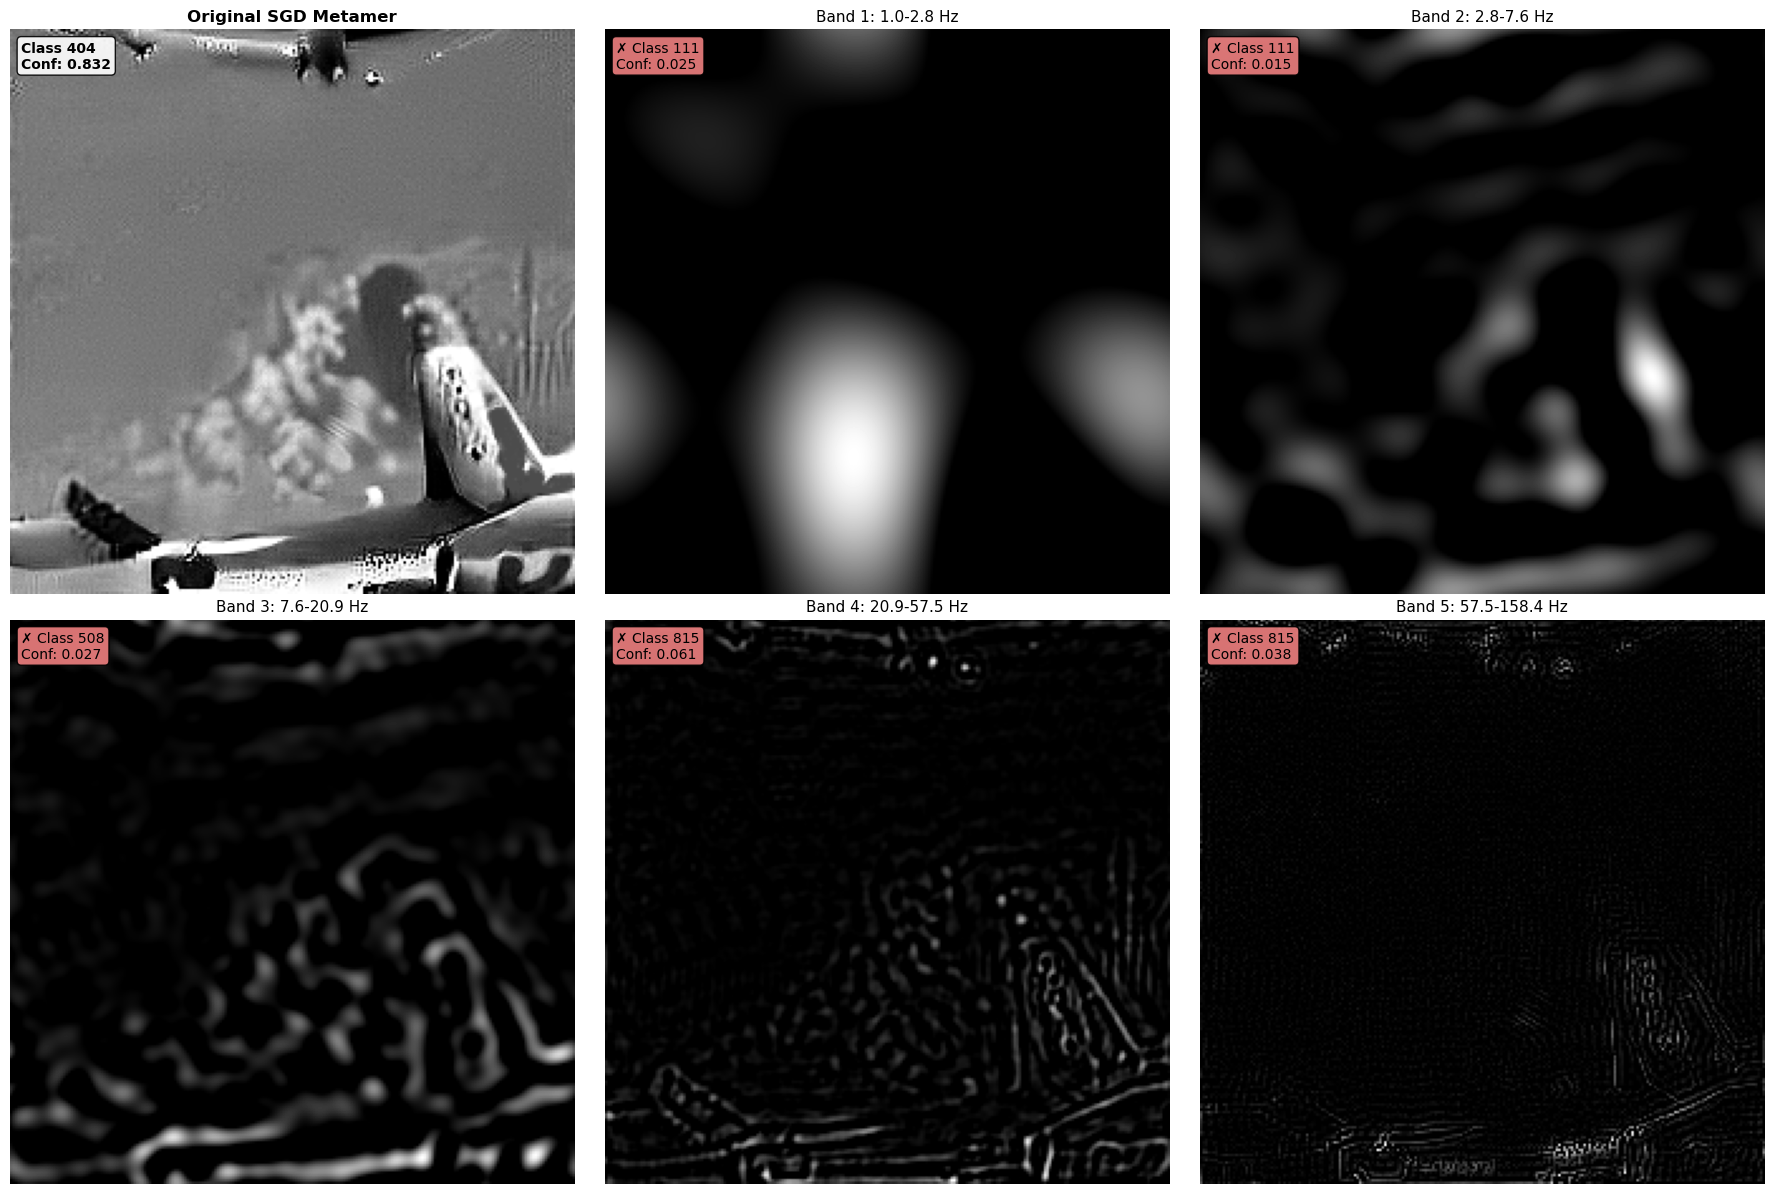


FREQUENCY BAND CLASSIFICATION ANALYSIS
Original SGD Metamer: Class 404 (confidence: 0.832)

Band 1: 1.0 - 2.8 Hz
  ✗ DIFFER: Class 111 (confidence: 0.025)
    Expected: Class 404

Band 2: 2.8 - 7.6 Hz
  ✗ DIFFER: Class 111 (confidence: 0.015)
    Expected: Class 404

Band 3: 7.6 - 20.9 Hz
  ✗ DIFFER: Class 508 (confidence: 0.027)
    Expected: Class 404

Band 4: 20.9 - 57.5 Hz
  ✗ DIFFER: Class 815 (confidence: 0.061)
    Expected: Class 404

Band 5: 57.5 - 158.4 Hz
  ✗ DIFFER: Class 815 (confidence: 0.038)
    Expected: Class 404

Summary: 0/5 bands match original classification (0.0%)
❌ Poor results. Most bands don't preserve the original classification.


In [25]:
# Get the SGD result
sgd_result = results.get('sgd', {})
if "error" in sgd_result:
    print("SGD optimization failed, cannot create band-passed images")
else:
    print("=== Band-Pass Analysis with Model Classification ===")

    # Get the adversarial image from Muon
    xadv_sgd = sgd_result["xadv"].squeeze().cpu().numpy()
    if xadv_sgd.shape[0] == 3:  # NCHW format
        xadv_sgd = np.rollaxis(xadv_sgd, 0, 3)

    # Convert to grayscale if it's color
    if len(xadv_sgd.shape) == 3:
        # Convert RGB to grayscale using luminance formula
        xadv_sgd = 0.299 * xadv_sgd[:, :, 0] + 0.587 * xadv_sgd[:, :, 1] + 0.114 * xadv_sgd[:, :, 2]

    # Define frequency bands on log scale
    rows, cols = xadv_sgd.shape
    max_freq = np.sqrt((rows//2)**2 + (cols//2)**2)

    # Create 5 frequency bands on log scale
    log_freqs = np.logspace(0, np.log10(max_freq), 6)  # 6 points for 5 bands
    freq_bands = [(log_freqs[i], log_freqs[i+1]) for i in range(len(log_freqs) - 1)]

    # Create band-passed images
    band_passed_images = []
    band_classifications = []

    print("Processing frequency bands...")
    for i, (low_freq, high_freq) in enumerate(freq_bands):
        print(f"  Band {i+1}: {low_freq:.1f} - {high_freq:.1f} Hz")

        # Apply band-pass filter
        filtered_img = apply_bandpass_grayscale(xadv_sgd, low_freq, high_freq)
        band_passed_images.append(filtered_img)

        # Get model classification for this band
        try:
            img_tensor = prepare_image_for_model(filtered_img)
            predictions = get_model_predictions(img_tensor, model)
            band_classifications.append(predictions)
            print(f"    → Top prediction: Class {predictions[1][0]} (confidence: {predictions[0][0]:.3f})")
        except Exception as e:
            print(f"    → Classification failed: {e}")
            band_classifications.append(None)

    # Get original image classification for comparison
    orig_tensor = prepare_image_for_model(xadv_sgd)
    orig_predictions = get_model_predictions(orig_tensor, model)
    orig_class = orig_predictions[1][0]

    print(f"\nOriginal SGD metamer: Class {orig_class} (confidence: {orig_predictions[0][0]:.3f})")

    # Create enhanced visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # Original image with prediction
    axes[0].imshow(np.clip(xadv_sgd, 0, 1), cmap='gray')
    pred_text = f"Class {orig_class}\nConf: {orig_predictions[0][0]:.3f}"
    axes[0].text(0.02, 0.98, pred_text, transform=axes[0].transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9),
                verticalalignment='top', fontsize=10, fontweight='bold')
    axes[0].set_title("Original SGD Metamer", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Band-passed images with predictions
    for i, (filtered_img, (low_freq, high_freq), classification) in enumerate(
        zip(band_passed_images, freq_bands, band_classifications)):

        # Display image
        axes[i + 1].imshow(np.clip(filtered_img, 0, 1), cmap='gray')

        # Add prediction text
        if classification is not None:
            pred_class = classification[1][0]
            pred_conf = classification[0][0]

            # Color code based on whether it matches original
            if pred_class == orig_class:
                bbox_color = "lightgreen"
                match_symbol = "✓"
            else:
                bbox_color = "lightcoral"
                match_symbol = "✗"

            pred_text = f"{match_symbol} Class {pred_class}\nConf: {pred_conf:.3f}"
            axes[i + 1].text(0.02, 0.98, pred_text, transform=axes[i + 1].transAxes,
                            bbox=dict(boxstyle="round,pad=0.3", facecolor=bbox_color, alpha=0.9),
                            verticalalignment='top', fontsize=10)
        else:
            axes[i + 1].text(0.02, 0.98, "Classification\nFailed", transform=axes[i + 1].transAxes,
                            bbox=dict(boxstyle="round,pad=0.3", facecolor="gray", alpha=0.9),
                            verticalalignment='top', fontsize=10)

        axes[i + 1].set_title(f"Band {i+1}: {low_freq:.1f}-{high_freq:.1f} Hz", fontsize=11)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Detailed analysis summary
    print("\n" + "=" * 60)
    print("FREQUENCY BAND CLASSIFICATION ANALYSIS")
    print("=" * 60)
    print(f"Original SGD Metamer: Class {orig_class} (confidence: {orig_predictions[0][0]:.3f})")
    print()

    matching_bands = 0
    total_bands = 0

    for i, ((low_freq, high_freq), classification) in enumerate(zip(freq_bands, band_classifications)):
        print(f"Band {i+1}: {low_freq:.1f} - {high_freq:.1f} Hz")

        if classification is not None:
            pred_class = classification[1][0]
            pred_conf = classification[0][0]
            total_bands += 1

            if pred_class == orig_class:
                print(f"  ✓ MATCH: Class {pred_class} (confidence: {pred_conf:.3f})")
                matching_bands += 1
            else:
                print(f"  ✗ DIFFER: Class {pred_class} (confidence: {pred_conf:.3f})")
                print(f"    Expected: Class {orig_class}")
        else:
            print("  ⚠ Classification failed")
        print()

    if total_bands > 0:
        match_percentage = (matching_bands / total_bands) * 100
        print(f"Summary: {matching_bands}/{total_bands} bands match original classification ({match_percentage:.1f}%)")
        
        if match_percentage >= 80:
            print("🎉 Excellent! Most frequency bands preserve the classification.")
        elif match_percentage >= 60:
            print("👍 Good! Majority of frequency bands preserve the classification.")
        elif match_percentage >= 40:
            print("⚠️  Mixed results. Some bands preserve classification.")
        else:
            print("❌ Poor results. Most bands don't preserve the original classification.")

    print("=" * 60)
